In [1]:
from scripts import indices, plot, validate
import config

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from pathlib import Path

Set up of input data: random samples of surface reflectance across all 8 PS bands, labeled by land cover class (generated via QGIS model)

In [2]:
fp_bands = Path(r'C:\\Users\\remot\\Documents\\Jerome\\03_Independent_Research\\20260630 Mangrove and Seagrass Monitoring\\03_Data_management\\02_Processed_data\\Shapefiles\\Hinatuan-SurigaoDelSur_PS8BandsSamples-Corrected_LandCoverNAMRIA_20210729.csv')

df_bands = pd.read_csv(fp_bands).drop(columns=['id', 'xcoord', 'ycoord', 'gmw1'])
# df_bands['LCM_CLASS'] = df_bands['LCM_CLASS'].astype('category')

band_names = [col for col in df_bands.columns if col.startswith('b')]
df_bands = indices.remove_outliers(df_bands, band_names, impute=False)

df_bands.head()

Number of outliers detected for band b1: 43
Number of outliers detected for band b2: 36
Number of outliers detected for band b3: 20
Number of outliers detected for band b4: 12
Number of outliers detected for band b5: 18
Number of outliers detected for band b6: 25
Number of outliers detected for band b7: 39
Number of outliers detected for band b8: 45


,LCM_CLASS,b1,b2,b3,b4,b5,b6,b7,b8
0,Annual Crop,74,261,510,560,443,288,1120,4128
1,Annual Crop,123,252,368,376,336,275,674,2816
2,Annual Crop,76,244,323,342,367,279,674,2457
3,Annual Crop,119,254,497,534,464,281,1007,4553
4,Annual Crop,186,313,423,422,383,316,628,2616


In [3]:
df_bands_melt = df_bands.melt(
    id_vars=['LCM_CLASS'],
    value_vars=band_names,
    var_name='band',
    value_name='sr'
)

df_bands_melt.head()

,LCM_CLASS,band,sr
0,Annual Crop,b1,74
1,Annual Crop,b1,123
2,Annual Crop,b1,76
3,Annual Crop,b1,119
4,Annual Crop,b1,186


Initial exploration: are mangroves spectrally separable from other dense terrestrial vegetation (e.g., perennial cropland, which dominates in the current AOI)

In [4]:
df_bands_melt['LCM_CLASS'].unique()

<ArrowStringArray>
[    'Annual Crop',    'Brush/Shrubs',        'Built-up', 'Mangrove Forest',
        'Fishpond',    'Inland Water',     'Open Forest',  'Perennial Crop']
Length: 8, dtype: str

In [5]:
all_veg_classes = [
    'Annual Crop', 
    'Brush/Shrubs', 
    'Mangrove Forest', 
    'Perennial Crop', 
    'Grassland', 
    'Open Forest'
]

dense_veg_classes = [
    'Mangrove Forest', 
    'Perennial Crop', 
    # 'Annual Crop', 
    # 'Brush/Shrubs'
]

First check: spectral signature chart 

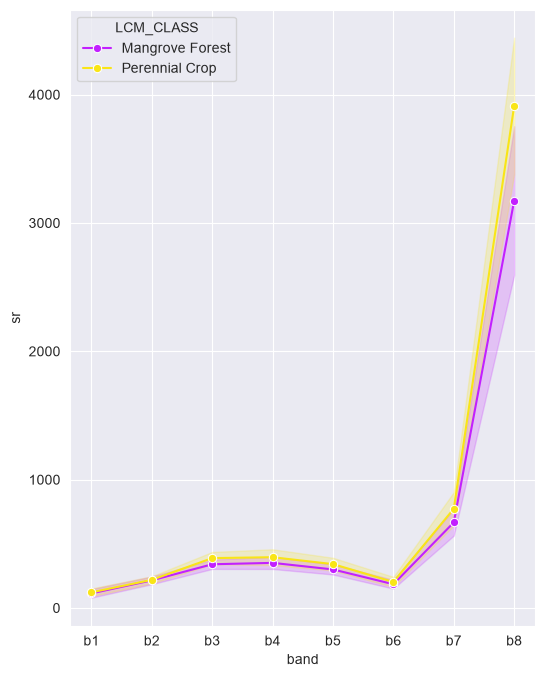

In [6]:
sns.set_style('darkgrid')
ax = plot.spectral_signature(
    data=df_bands_melt,
    category_column='LCM_CLASS',
    value_column='sr',
    band_column='band',
    cats_compared=dense_veg_classes
)

ax.figure.set_size_inches(6, 8)

Looking closer: boxplots to see if any band shows little overlap (i.e., good separability) between mangrove & perennial crop

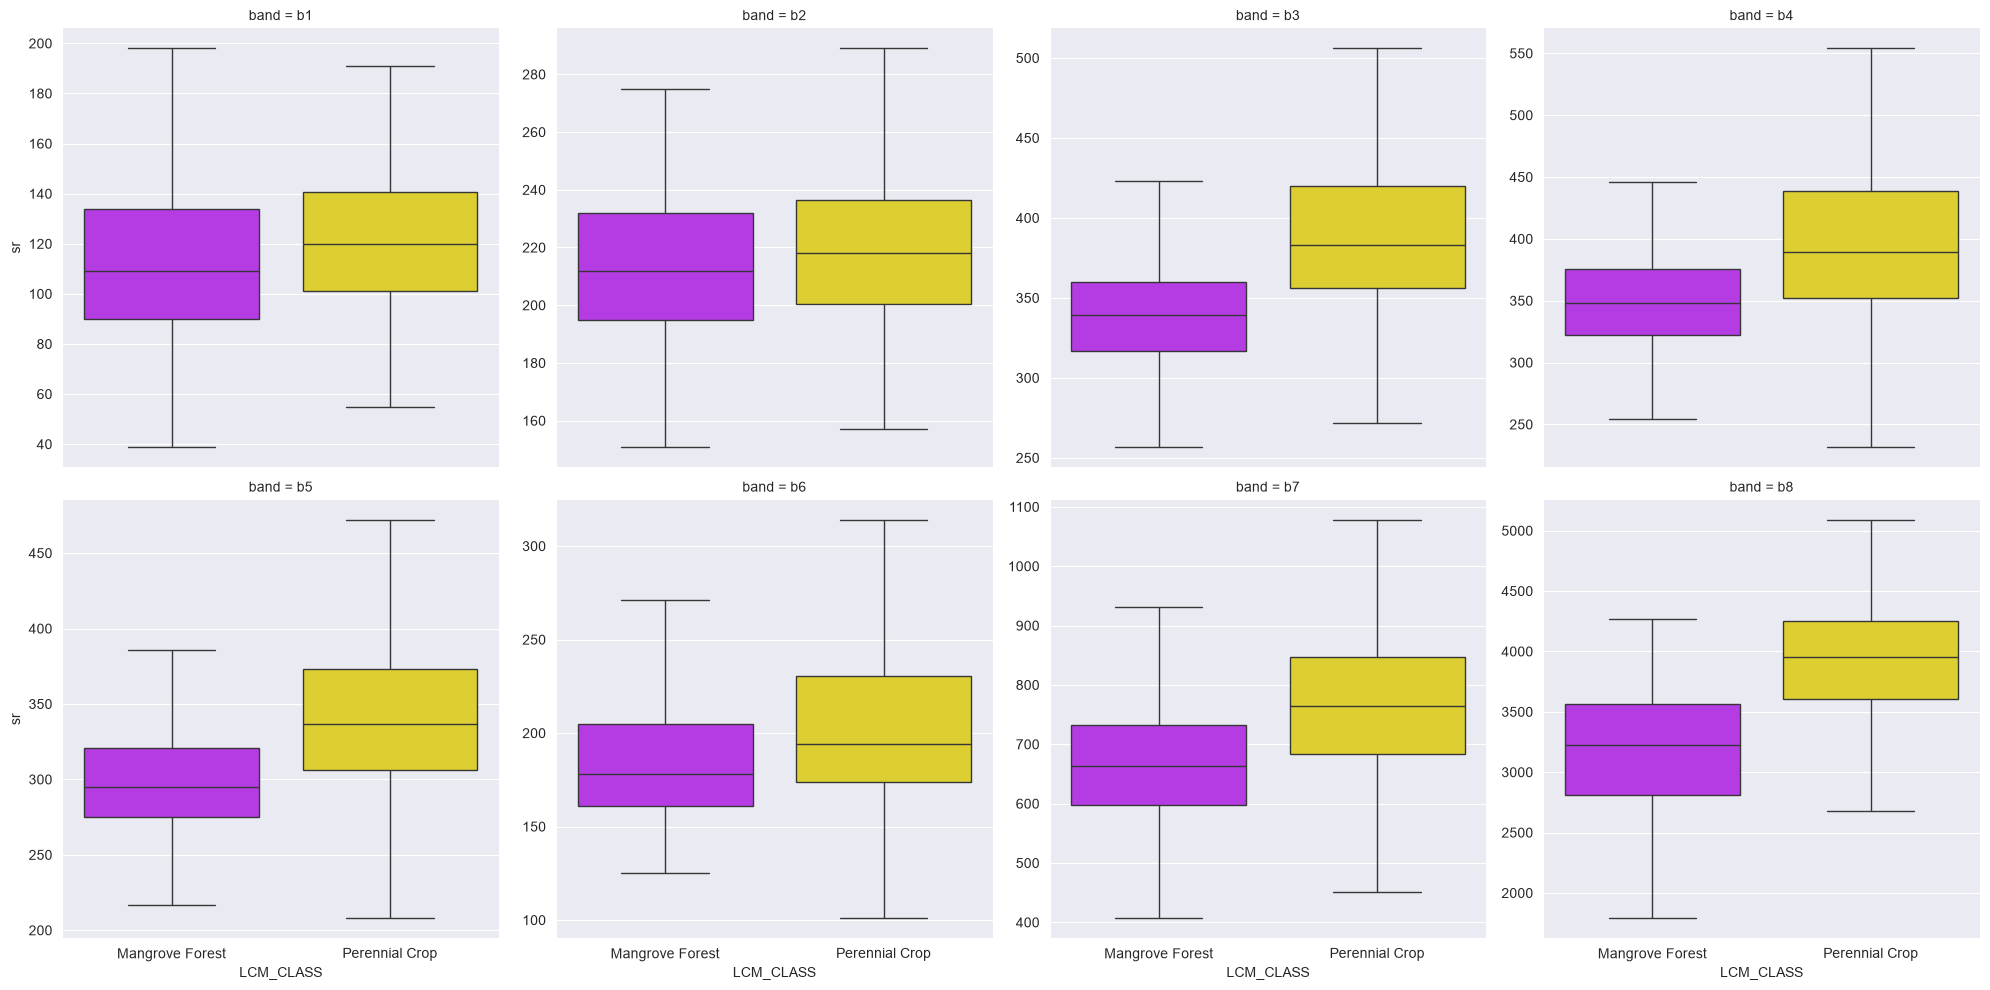

In [7]:
plot.boxplot_bands(
    data=df_bands_melt,
    category_column='LCM_CLASS',
    value_column='sr',
    band_column='band',
    cats_compared=dense_veg_classes,
    col_wrap=4
)

Could the two classes be more separable if viewed from two dimensions?

<Axes: xlabel='b8', ylabel='b7'>

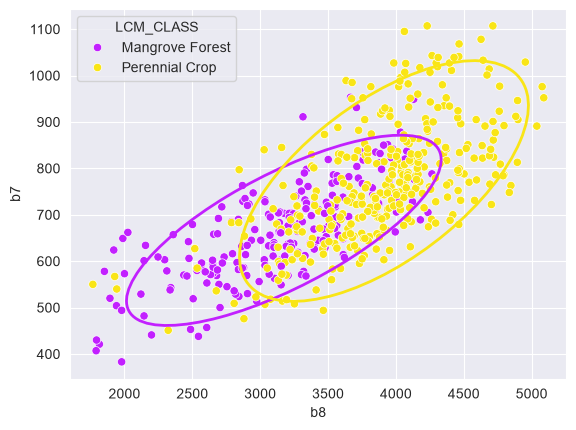

In [8]:
plot.scatterplot_bands(
    data=df_bands,
    band_x='b8',
    band_y='b7',
    category_column='LCM_CLASS',
    n_std=2,
    cats_compared=dense_veg_classes
)

Beyond simple visual assessments, let's quantitatively measure their separability: first, by taking the per-band means and standard deviation for the two classes

In [9]:
df_stats = validate.agg_per_class(
    data=df_bands,
    category_column='LCM_CLASS',
    band_names=band_names,
    cats_compared=dense_veg_classes,
)

df_stats.head()

,LCM_CLASS,b1_mean,b1_std,b2_mean,b2_std,b3_mean,b3_std,b4_mean,b4_std,b5_mean,b5_std,b6_mean,b6_std,b7_mean,b7_std,b8_mean,b8_std
0,Mangrove Forest,113.466063,33.430185,214.932127,29.870629,340.248869,36.366275,351.022624,47.532424,299.805430,39.332420,184.624434,33.974846,666.380090,102.490489,3173.914027,579.585296
1,Perennial Crop,121.413994,30.188260,218.924198,27.708699,388.131195,47.952190,395.128280,61.816706,341.250729,49.428974,202.323615,39.407419,772.693878,129.674839,3911.597668,532.142944


In [10]:
df_separability = validate.get_separability(
    df_stats=df_stats,
    category_column='LCM_CLASS',
    category_a='Mangrove Forest',
    category_b='Perennial Crop',
    band_names=band_names
)

df_separability.head()

,band,m_statistic,jm_distance
0,b1,0.124931,0.143714
1,b2,0.069332,0.087208
2,b3,0.567875,0.569796
3,b4,0.403347,0.430082
4,b5,0.466929,0.476602


Jeffries-Matusita distance for mangrove vs. perennial crop for each band. Horizontal line (=1.88) is the threshold for sufficient separability.

<Axes: xlabel='band', ylabel='jm_distance'>

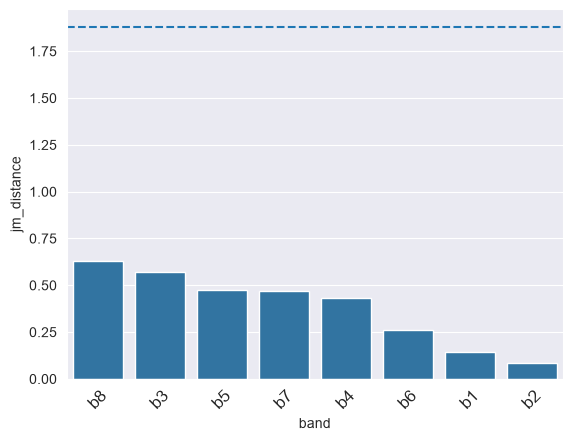

In [11]:
plot.separability_2class(
    data_separability=df_separability,
    separability_column='jm_distance',
    band_column='band',
    threshold=1.88
)

Looks like the two classes are not separable based on specific bands. Next, let's try out VNIR-only mangrove-specific indices described in existing literature.

Let's first calculate NDVI and NDWI, which are NOT mangrove-specific indices but are used as building blocks for ones later on.

In [12]:
ndvi = indices.normalized_difference_2band(
    band_a=df_bands.b8,
    band_b=df_bands.b6
)

ndwi = indices.normalized_difference_2band(
    band_a=df_bands.b4,
    band_b=df_bands.b8
)

Next, let's proceed to the mangrove-specific indices.

In [13]:
cmri = ndvi - ndwi

mmri = indices.normalized_difference_2band(
    band_a=np.abs(ndwi),
    band_b=np.abs(ndvi)
)

mvdi = (
    ((df_bands.b7 - df_bands.b6) * (df_bands.b8 + df_bands.b6))
    / ((df_bands.b8 - df_bands.b7) * (df_bands.b8 - df_bands.b6))
)

Let's compile everything into one DataFrame.

In [14]:
df_indices = df_bands.copy(deep=True).drop(columns=band_names)
index_names = ['ndvi', 'ndwi', 'cmri', 'mmri', 'mvdi']
df_indices[index_names] = np.array([ndvi, ndwi, cmri, mmri, mvdi]).T
# df_indices = indices.remove_outliers(df_indices, index_names, impute=False)
df_indices.head()

,LCM_CLASS,ndvi,ndwi,cmri,mmri,mvdi
0,Annual Crop,0.869565,-0.761092,1.630657,-0.066521,0.318085
1,Annual Crop,0.822064,-0.764411,1.586475,-0.036340,0.226594
2,Annual Crop,0.796053,-0.755627,1.551680,-0.026053,0.278294
3,Annual Crop,0.883740,-0.790053,1.673793,-0.055973,0.231672
4,Annual Crop,0.784447,-0.722186,1.506633,-0.041325,0.200066


In [15]:
df_indices_melt = df_indices.melt(
    id_vars=['LCM_CLASS'],
    value_vars=index_names,
    value_name='value',
    var_name='index'
)

df_indices_melt.head()

,LCM_CLASS,index,value
0,Annual Crop,ndvi,0.869565
1,Annual Crop,ndvi,0.822064
2,Annual Crop,ndvi,0.796053
3,Annual Crop,ndvi,0.883740
4,Annual Crop,ndvi,0.784447


Now that we have the index values, let's visually assess via boxplots:

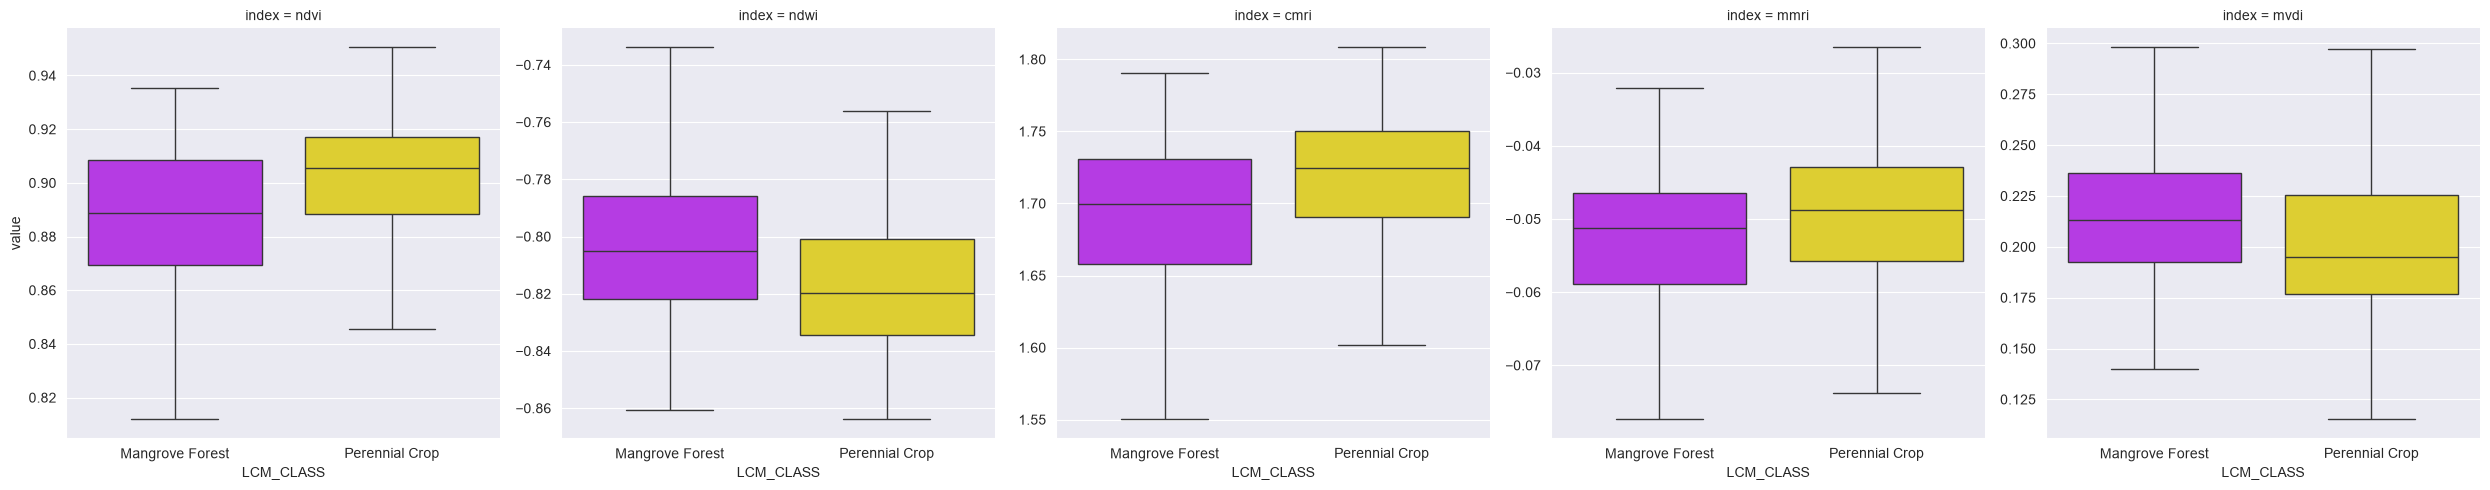

In [16]:
plot.boxplot_bands(
    data=df_indices_melt,
    category_column='LCM_CLASS',
    value_column='value',
    band_column='index',
    cats_compared=dense_veg_classes
)

...and also two-dimensionally via scatterplot:

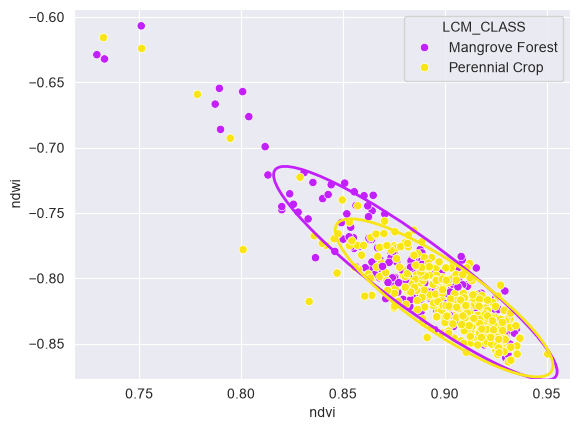

In [17]:
ax = plot.scatterplot_bands(
    data=df_indices,
    band_x='ndvi',
    band_y='ndwi',
    category_column='LCM_CLASS',
    cats_compared=dense_veg_classes,
    n_std=2
)

# ax.set_ylim(-2,2)

In [18]:
# sns.displot(
#     data=df_indices_melt[df_indices_melt['LCM_CLASS'].isin(dense_veg_classes)],
#     x='value',
#     col='index',
#     kind='hist',
#     hue='LCM_CLASS',
#     palette=config.PALETTE_LAND_COVER,
#     common_bins=False,
#     common_norm=False,
#     facet_kws=dict(sharex=False)
# )

Not looking great. Let's confirm our suspicions by calculating and plotting the separability metrics.

In [19]:
df_indices_stats = validate.agg_per_class(
    data=df_indices,
    category_column='LCM_CLASS',
    band_names=index_names,
    cats_compared=dense_veg_classes
)

df_indices_stats

,LCM_CLASS,ndvi_mean,ndvi_std,ndwi_mean,ndwi_std,cmri_mean,cmri_std,mmri_mean,mmri_std,mvdi_mean,mvdi_std
0,Mangrove Forest,0.885596,0.034805,-0.796129,0.040887,1.681726,0.074178,-0.053496,0.011413,0.220174,0.041602
1,Perennial Crop,0.899694,0.026725,-0.814983,0.030234,1.714676,0.054870,-0.049535,0.009978,0.203559,0.038734


In [20]:
df_indices_separ = validate.get_separability(
    df_stats=df_indices_stats,
    category_column='LCM_CLASS',
    category_a='Mangrove Forest',
    category_b='Perennial Crop',
    band_names=index_names
).rename(columns={'band': 'index'})

df_indices_separ

,index,m_statistic,jm_distance
0,ndvi,0.229117,0.290291
1,ndwi,0.265086,0.332331
2,cmri,0.255336,0.325043
3,mmri,0.185145,0.206551
4,mvdi,0.206818,0.211566


Looks like none of them come even close to the threshold for good separability.

<Axes: xlabel='index', ylabel='jm_distance'>

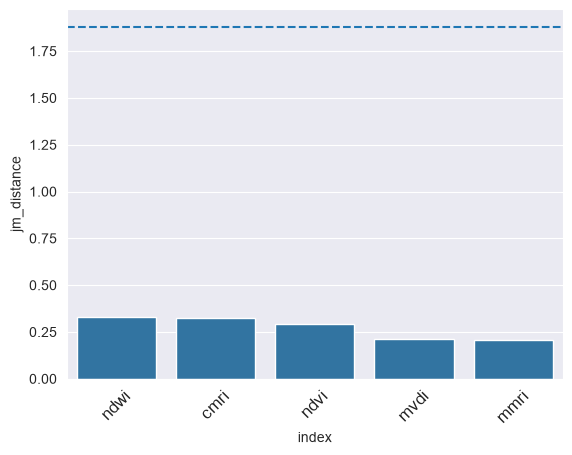

In [21]:
plot.separability_2class(
    data_separability=df_indices_separ,
    separability_column='jm_distance',
    band_column='index',
    threshold=1.88
)

Let's move on to analyzing the spectral signatures and coming up with our own spectral indices. To start, let's re-plot the box plots per band.

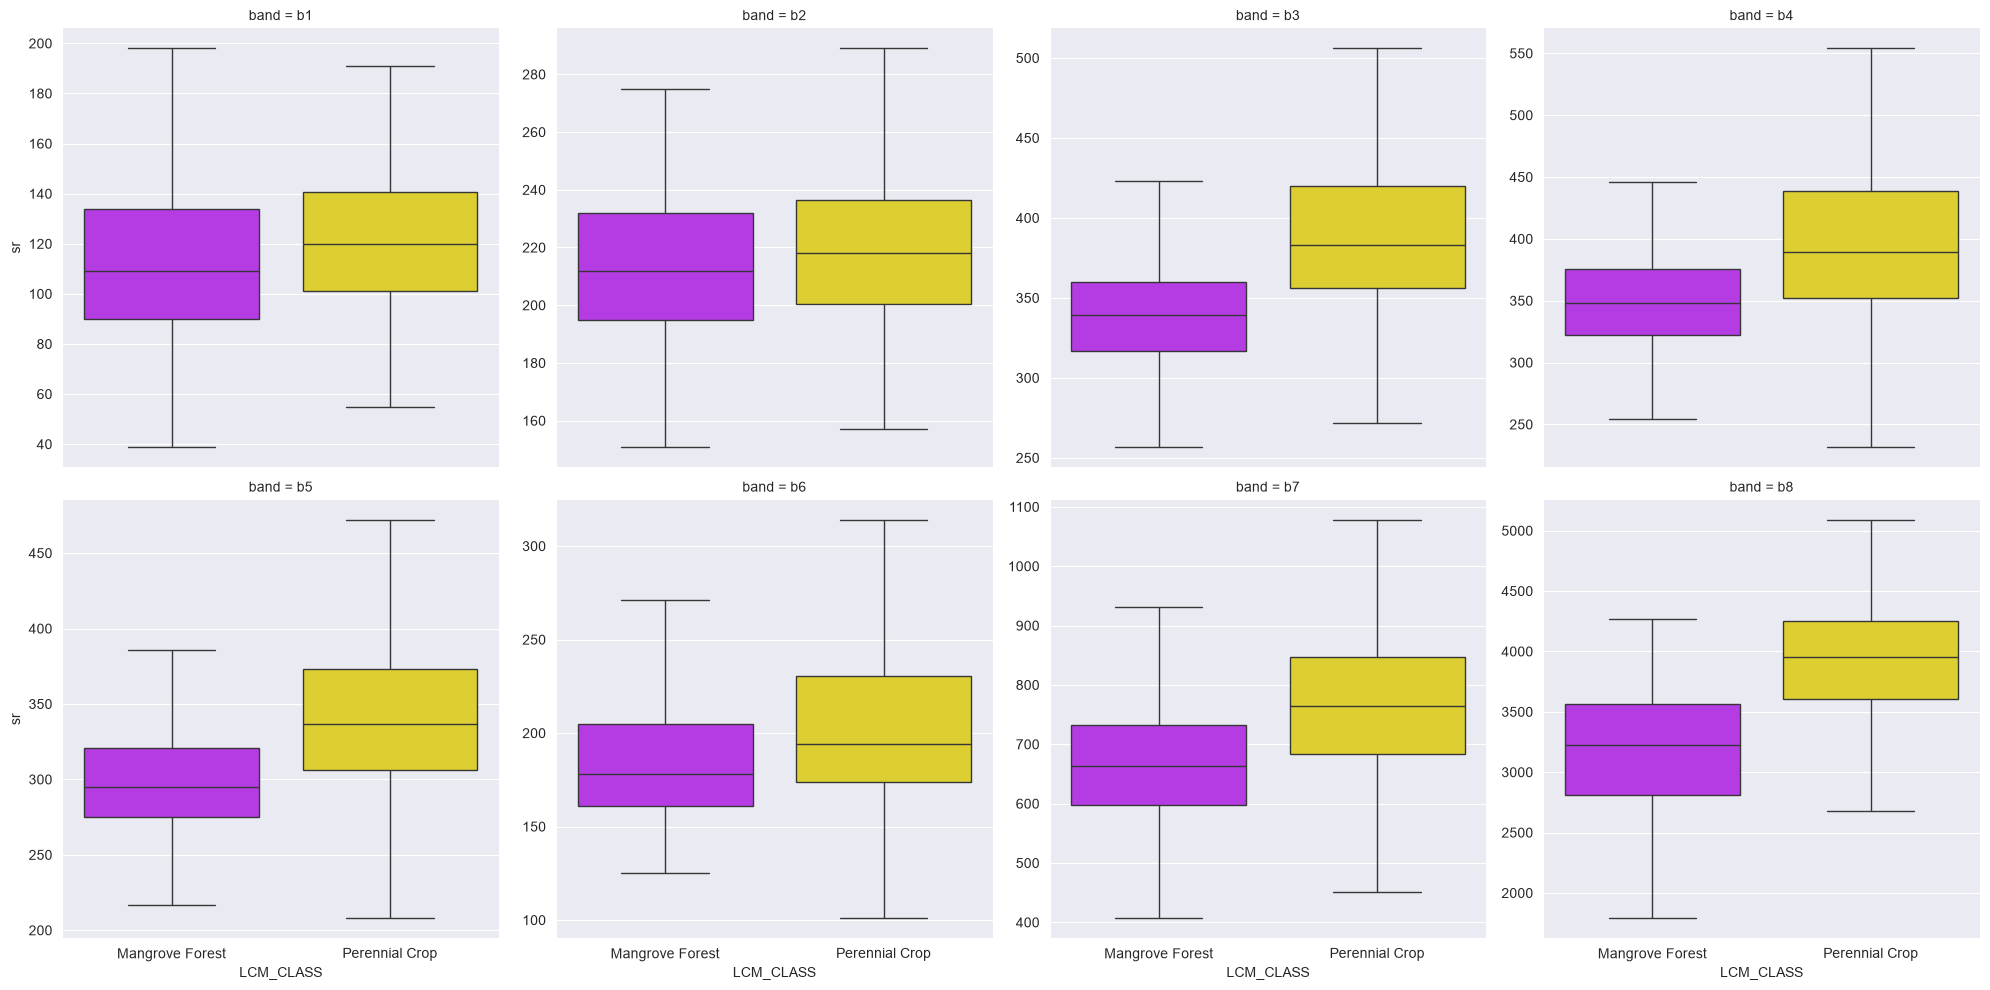

In [22]:
plot.boxplot_bands(
    data=df_bands_melt,
    category_column='LCM_CLASS',
    band_column='band',
    value_column='sr',
    cats_compared=dense_veg_classes,
    col_wrap=4
)

It looks like for all bands that have some semblance of separability, mangrove reflectance is lower than perennial crop. For bands 1 and 2 (coastal blue and blue), there is virtually no difference between the two classes. Which of the remaining bands are most separable? Let's re-plot the separability metrics.

<Axes: xlabel='band', ylabel='jm_distance'>

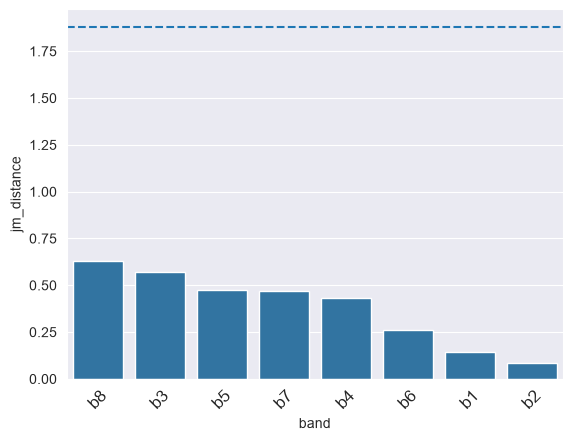

In [23]:
plot.separability_2class(
    data_separability=df_separability,
    separability_column='jm_distance',
    band_column='band',
    threshold=1.88
)

Looks like band 8 (NIR) is the most separable, followed by 5 (yellow), 3 (green I), 7 (red edge), 6 (red), and 4 (green). Could we exploit these somehow in coming up with our own spectral indices? 

In [24]:
# Constant b1 & b2 --> constant numerator; smaller b3 & b5 --> smaller denominator --> larger ratio
mrei1 = 5 * (df_bands.b2 + df_bands.b1) / (df_bands.b3 + df_bands.b5 + config.DENOMINATOR_ERROR_TERM)

# Constant b1 & b2 --> constant numerator; smaller b3 & b4 --> smaller denominator --> larger ratio
mrei2 = 5 * (df_bands.b2 + df_bands.b1) / (df_bands.b3 + df_bands.b4 + config.DENOMINATOR_ERROR_TERM)

# Taken from documentation (past attempt)
mrei3 = np.abs(df_bands.b7 - df_bands.b4) / np.abs(df_bands.b8 - df_bands.b4 + config.DENOMINATOR_ERROR_TERM)

# Constant b1 & b2 --> constant denominator; Lower b8 & constant b2 --> smaller numerator --> smaller ratio
mrei4 = (df_bands.b8 - df_bands.b2) / (df_bands.b2 + df_bands.b1 + config.DENOMINATOR_ERROR_TERM)

# Taken from documentation (past attempt)
mrei5 = (df_bands.b7 - df_bands.b6) / (df_bands.b8 - df_bands.b6 + config.DENOMINATOR_ERROR_TERM)

# Constant b1 & b2 --> constant numerator; smaller b8 --> smaller denominator --> larger ratio
mrei6 = 5 * (df_bands.b2 + df_bands.b1) / (df_bands.b8 + config.DENOMINATOR_ERROR_TERM)

# Taken from documentation (past attempt)
mrei7 = (df_bands.b7 - df_bands.b4) / (df_bands.b8 - df_bands.b4 + config.DENOMINATOR_ERROR_TERM)

Let's compile all of these into a single dataframe.

In [25]:
df_mrei = df_bands.copy(deep=True).drop(columns=band_names)
mrei_names = [f'mrei{i+1}' for i in range(7)]
df_mrei[mrei_names] = np.array([mrei1, mrei2, mrei3, mrei4, mrei5, mrei6, mrei7]).T
# df_mrei = indices.remove_outliers(df_mrei, mrei_names, impute=False)
df_mrei.head()

,LCM_CLASS,mrei1,mrei2,mrei3,mrei4,mrei5,mrei6,mrei7
0,Annual Crop,1.757608,1.565421,0.156951,11.543284,0.216667,0.405766,0.156951
1,Annual Crop,2.663352,2.520161,0.122131,6.837333,0.157025,0.665838,0.122131
2,Annual Crop,2.318841,2.406015,0.156974,6.915625,0.181359,0.651201,0.156974
3,Annual Crop,1.940687,1.808923,0.117691,11.525469,0.169944,0.409620,0.117691
4,Annual Crop,3.095533,2.952663,0.093892,4.615230,0.135652,0.953746,0.093892


In [26]:
df_mrei_melt = df_mrei.melt(
    id_vars=['LCM_CLASS'],
    value_vars=mrei_names,
    value_name='value',
    var_name='index'
)

df_mrei_melt.head()

,LCM_CLASS,index,value
0,Annual Crop,mrei1,1.757608
1,Annual Crop,mrei1,2.663352
2,Annual Crop,mrei1,2.318841
3,Annual Crop,mrei1,1.940687
4,Annual Crop,mrei1,3.095533


Let's visually assess each of these new indices for their ability to separate mangroves from non-mangroves via boxplots and scatterplot.

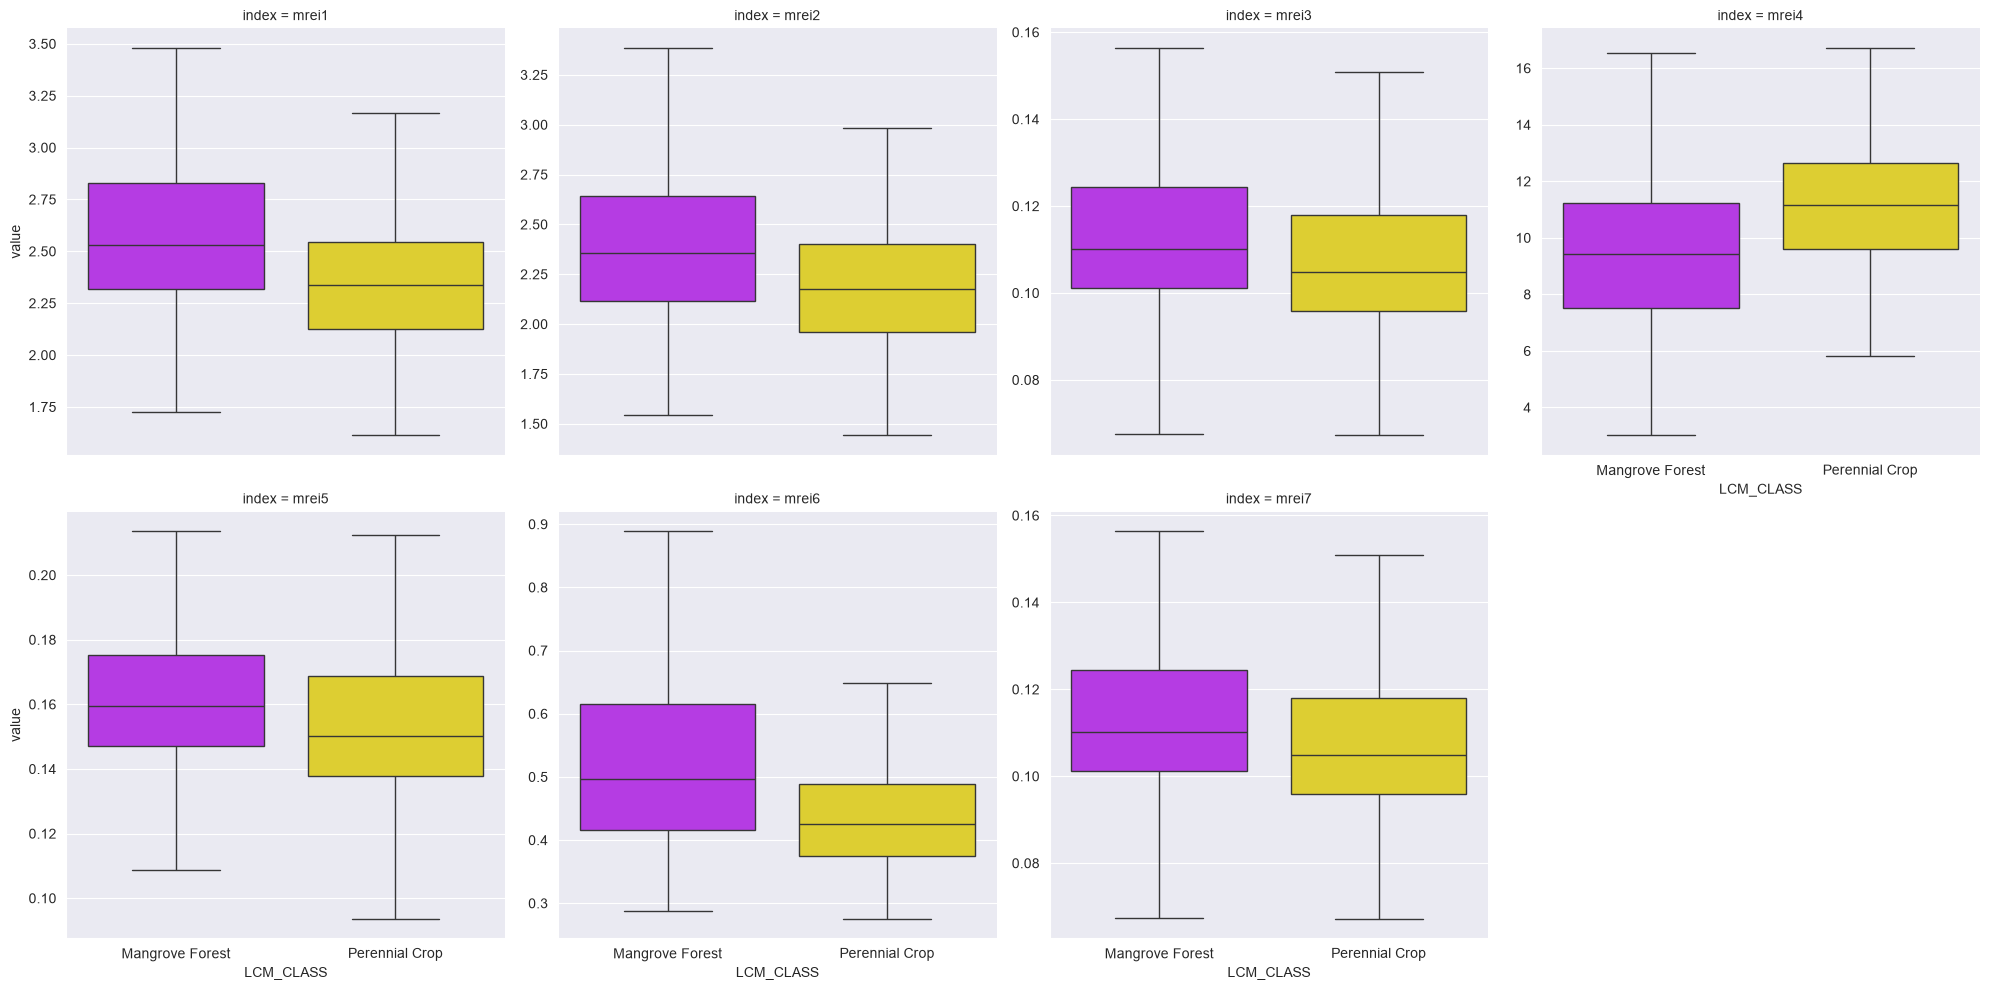

In [27]:
plot.boxplot_bands(
    data=df_mrei_melt,
    category_column='LCM_CLASS',
    value_column='value',
    band_column='index',
    cats_compared=dense_veg_classes,
    col_wrap=4
)

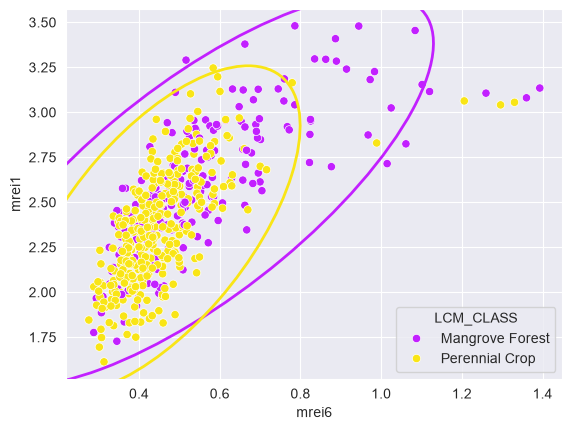

In [28]:
ax = plot.scatterplot_bands(
    data=df_mrei,
    band_x='mrei6',
    band_y='mrei1',
    category_column='LCM_CLASS',
    cats_compared=dense_veg_classes,
    n_std=3
)

# ax.set_ylim(-1, 1)

Not too separable visually. What do the separability metrics say?

In [29]:
df_mrei_stats = validate.agg_per_class(
    data=df_mrei,
    category_column='LCM_CLASS',
    band_names=mrei_names,
    cats_compared=dense_veg_classes
)

df_mrei_stats

,LCM_CLASS,mrei1_mean,mrei1_std,mrei2_mean,mrei2_std,mrei3_mean,mrei3_std,mrei4_mean,mrei4_std,mrei5_mean,mrei5_std,mrei6_mean,mrei6_std,mrei7_mean,mrei7_std
0,Mangrove Forest,2.569025,0.363553,2.386512,0.380285,0.111779,0.020574,9.404521,2.795711,0.162086,0.022627,0.546731,0.194292,0.111779,0.020574
1,Perennial Crop,2.345691,0.304245,2.190702,0.311877,0.107469,0.018617,11.102134,2.260665,0.153844,0.022741,0.445859,0.117775,0.107469,0.018617


In [30]:
df_mrei_separ = validate.get_separability(
    df_mrei_stats,
    category_column='LCM_CLASS',
    category_a='Mangrove Forest',
    category_b='Perennial Crop',
    band_names=mrei_names
).rename(columns={'band': 'mrei'})

df_mrei_separ

,mrei,m_statistic,jm_distance
0,mrei1,0.334434,0.350448
1,mrei2,0.282896,0.310471
2,mrei3,0.109986,0.130307
3,mrei4,0.335737,0.359840
4,mrei5,0.181674,0.180960
5,mrei6,0.323240,0.455397
6,mrei7,0.109986,0.130307


<Axes: xlabel='mrei', ylabel='jm_distance'>

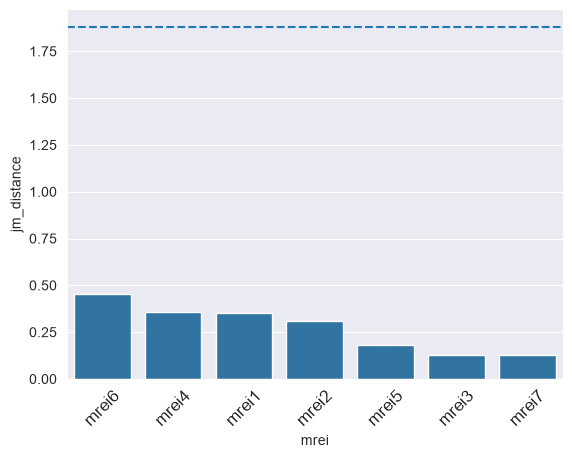

In [31]:
plot.separability_2class(
    df_mrei_separ,
    separability_column='jm_distance',
    band_column='mrei',
    threshold=1.88
)

None of the manually-designed indices even approach the threshold for good separability.

Let's try a different approach. What if we let the data speak for itself? First, let's stay within the realm of algebraic and illumination-invariant spectral indices using the Spectral Feature Polynomial (SFP) tool.

In [32]:
indices.spectral_feature_polynomial?

Signature:
indices.spectral_feature_polynomial(
    fp_data: str | pathlib.Path,
    category_column: str,
    target_category: str,
    band_names: list[str],
    fp_script: str | pathlib.Path = WindowsPath('C:/Users/remot/Documents/Jerome/06_Tools/spectral-feature-polynomial-main/sfp_satellite.py'),
)
Docstring:
Runs the Spectral Feature Polynomial tool, which takes a multispectral
dataset in CSV form and discovers a single algebraic index that best
separates a target land cover class from everything else.

Specifically, this function uses the `sfp_satellite.py` script, which
limits the search to illumination-invariant families (2-band normalized
difference (ND); 3-band ND, and normalized curve).

The resulting index is a compact algebraic function of a few bands. It
is easily interpretable and deployable on any remote-sensing plantform,
and requires no standardization/normalization statistics before input.

Source: Lotfi, A., Carter, A., Ha, T., Meysami, M., Nketia, K., & 
Shirtliff

Here is an example of how to use this function.

In [33]:
result = indices.spectral_feature_polynomial(
    fp_data=fp_bands,
    category_column='LCM_CLASS',
    target_category='Mangrove Forest',
    band_names=band_names
)

print(result)

{'best_index': 'ND[b5,b7]*NCurv[b1,b2,b5]', 'n_folds': '10', 'mean_accuracy': '73.76%', 'median_accuracy': '72.99%', 'min_accuracy': '70.11%'}


Let's run the tool for different combinations of bands and land cover classes. Later on, we can manually compute the resulting indices and assess their separability.

Let's start by exporting versions of our bands dataset with different combinations of land cover categories, to test whether accuracy increases if the categorical range is more focused towards the core differentiation we want to make (mangrove vs. non-mangrove vegetation):
- all classes (outliers removed)
- vegetation only
- mangrove & perennial crop only

In [34]:
fp_bands_all_class = Path('interim') / fp_bands.name.replace('LandCover', 'AllClasses')
fp_bands_veg_only = Path('interim') / fp_bands.name.replace('LandCover', 'VegOnly')
fp_bands_dense_veg = Path('interim') / fp_bands.name.replace('LandCover', 'DenseVegOnly')

df_bands.to_csv(fp_bands_all_class)
df_bands[df_bands['LCM_CLASS'].isin(all_veg_classes)].to_csv(fp_bands_veg_only)
df_bands[df_bands['LCM_CLASS'].isin(dense_veg_classes)].to_csv(fp_bands_dense_veg)

Next, let's set up the different combinations of bands to be included, to test whether extra bands improve or merely confound the results.

In [35]:
band_names

['b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'b8']

In [36]:
vnir_band_names = [f'b{i+1}' for i in range(8) if i % 2 != 0]
separable_band_names = ['b3', 'b4', 'b5', 'b7', 'b8']

band_combos = {
    'all_bands': band_names,
    'vnir_only': vnir_band_names,
    'separable': separable_band_names
}

Next, let's run the SFP tool for all combinations of bands and land cover classes.

In [42]:
sfp_results = []

for lc_combo in ['AllClasses', 'VegOnly', 'DenseVegOnly']: 
    for band_combo in list(band_combos.keys()):
        fp = list(Path('interim').glob(f'*{lc_combo}*.csv'))[0]

        lc_combo_name = "_".join(''.join([' ' + char.lower() if char.isupper() else char for char in lc_combo]).split())
        result = {
            'lc_combo': lc_combo_name,
            'band_combo': band_combo
        }

        result = result | indices.spectral_feature_polynomial(
            fp_data=fp,
            category_column='LCM_CLASS',
            target_category='Mangrove Forest',
            band_names=band_combos[band_combo]
        )

        sfp_results.append(result)

df_sfp = pd.DataFrame(sfp_results)
df_sfp.sort_values(by='mean_accuracy', ascending=False)       

,lc_combo,band_combo,best_index,n_folds,mean_accuracy,median_accuracy,min_accuracy
0,all_classes,all_bands,ND3[-b2+b3+b6]*ND3[+b5-b7+b8],10,76.54%,76.19%,66.67%
3,veg_only,all_bands,ND3[-b2+b3+b6]*ND3[+b5-b7+b8],10,75.57%,76.13%,68.42%
6,dense_veg_only,all_bands,ND3[-b2+b3+b6]*ND3[+b5-b7+b8],10,75.57%,76.13%,68.42%
1,all_classes,vnir_only,"ND3[-b2+b4+b6]*NCurv[b2,b4,b8]",10,72.89%,73.02%,65.08%
4,veg_only,vnir_only,"ND3[-b2+b4+b6]*NCurv[b2,b4,b8]",10,70.94%,71.43%,64.91%
7,dense_veg_only,vnir_only,"ND3[-b2+b4+b6]*NCurv[b2,b4,b8]",10,70.94%,71.43%,64.91%
2,all_classes,separable,ND3[-b4+b5+b7]*ND3[+b5-b7+b8],10,64.98%,65.08%,64.06%
5,veg_only,separable,"ND3[-b4+b5+b7]*NCurv[b5,b7,b8]",10,63.13%,62.83%,59.65%
8,dense_veg_only,separable,"ND3[-b4+b5+b7]*NCurv[b5,b7,b8]",10,63.13%,62.83%,59.65%


Looking at the results, there are 9 specific combinations of land cover x bands included, BUT only 6 unique resulting spectral indices. 

Vegetation-only and dense-vegetation trials resulted in the same best-performing indices. 

Accuracy is highest when all bands are included, followed by VNIR-only. 

Using only the most separable bands (as determined earlier in this notebook) performed the worst.

Let's apply the generated index formulas to the data and assess their separability for mangroves.